# Seaborn Titanic 데이터셋 이진 분류 모델
이 노트북은 **TensorFlow/Keras**를 사용하여 타이타닉 생존 여부(survived)를 예측하는 딥러닝 모델을 구축하고 평가합니다.

In [1]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.22.0-rc0


In [2]:
# 2. 데이터 로드
df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# 3. 데이터 전처리
# 주요 특성 선택 및 결측치 처리
cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[cols].copy()
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 범주형 데이터 원-핫 인코딩
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=float)

# 데이터 분리
X = df.drop('survived', axis=1).values.astype(np.float32)
y = df['survived'].values.astype(np.float32)

# 학습/테스트 분할
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(len(X) * 0.8)
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

In [4]:
# 4. Keras 모델 구조 정의 (로지스틱 회귀와 유사한 구조)
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 이진 분류를 위한 시그모이드 출력
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. 모델 학습 (EarlyStopping 포함)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=16, callbacks=[early_stopping], verbose=1)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.4851 - loss: 3.1482 - val_accuracy: 0.6503 - val_loss: 2.1874
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6714 - loss: 1.2724 - val_accuracy: 0.6643 - val_loss: 1.2561
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7276 - loss: 0.8261 - val_accuracy: 0.6783 - val_loss: 0.8203
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7065 - loss: 0.6453 - val_accuracy: 0.6853 - val_loss: 0.6543
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7030 - loss: 0.6133 - val_accuracy: 0.6923 - val_loss: 0.6312
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7047 - loss: 0.6070 - val_accuracy: 0.6643 - val_loss: 0.6257
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7047 - loss: 0.5977 - val_accuracy: 0.6713 - val_loss: 0.6195
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7065 - loss: 0.5890 - val_accuracy: 0.6713 -

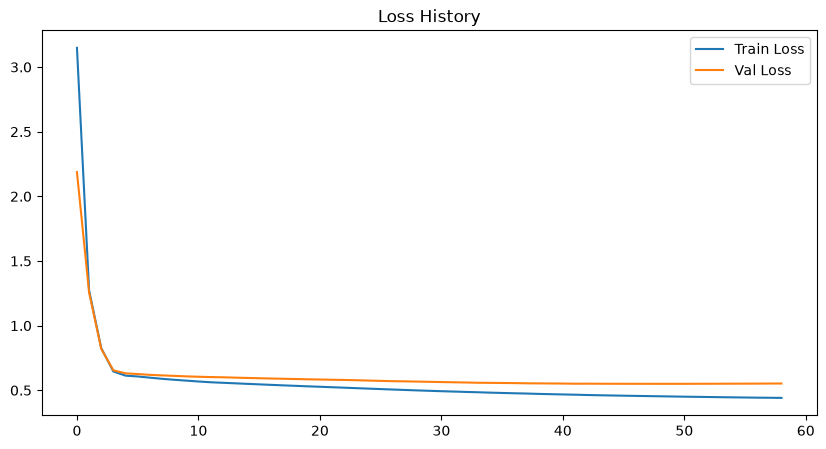

In [6]:
# 6. 학습 손실(Loss) 차트 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


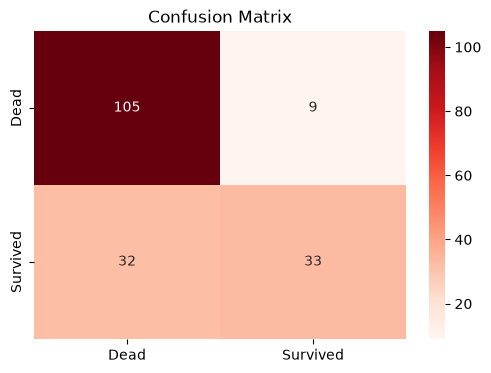

In [9]:
# 7. 오차 행렬(Confusion Matrix) 시각화
from sklearn.metrics import confusion_matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Dead', 'Survived'], yticklabels=['Dead', 'Survived'])
plt.title('Confusion Matrix')
plt.show()